<a href="https://colab.research.google.com/github/marianaolmedo/Simulacion-II/blob/main/Modelo_MM1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Línea de espera con un servidor**
En este trabajo analizamos una línea de espera con un servidor, cuyo modelo matemático corresponde a un sistema M/M/1:


*   Llegadas Poisson con tasa $λ$

* Tiempos de servicio exponenciales con tasa $\mu$

* Un solo servidor

Objetivo:

1. Simular el sistema mediante eventos discretos.


2. Calcular métricas como:

   *   Número promedio de Clientes en el Sistema $L$
   *   Número promedio de Clientes en la Fila $L_q$
   *   Tiempo promedio en el Sistema (Espera + Servicio) $W$
   *   Tiempo promedio en la Fila $W_q$
   *   Probabilidades $P(n)$ de estados

3. Comparar los resultados con las fórmulas analíticas exactas.



**Pasos para construir la Simulación:**

1. Poner las librerias necesarias para hacer funcionar el código:

In [77]:
import numpy as np
from random import expovariate
from statistics import mean
from math import inf
import matplotlib.pyplot as plt

2. Parámetros y variables del modelo

In [78]:
lamda = 4.0     # tasa de llegadas
mu = 6.0        # tasa de servicio
Num_PK = 1000   # número de clientes a simular

t = 0.0
N = 0                # número de clientes en el sistema
count = 0            # clientes que completaron servicio
t_evento_anterior = 0.0
tll = expovariate(lamda)
ts = inf

tll_Data = []
ts_Data = []
tss_Data = [] # tiempo de inicio de servicio para Wq

area = []
area_q = []   # área para Lq
tiempo_en_estado = {}

X = []   # tiempos de eventos
Y = []   # número de clientes después del evento


3. Simulación:

In [93]:
while count < Num_PK:
  # Determinar próximo evento
  if tll < ts:
    t = tll
    tll_Data.append(t)

  else:
    t = ts
    ts_Data.append(t)

  X.append(t)
  Y.append(N)
  # Tiempo transcurrido desde el último evento
  dt = t - t_evento_anterior
  t_evento_anterior = t

  if N not in tiempo_en_estado:
    tiempo_en_estado[N] = 0.0
  tiempo_en_estado[N] = tiempo_en_estado[N] + dt

  # Área para L = E[N]
  area.append(dt * N)

  # Área para Lq = E[Nq]
  Nq = max(N - 1, 0)
  area_q.append(dt * Nq)

  # Procesar evento
  if t == tll:
    N = N + 1
    tll = t + expovariate(lamda)
    if N == 1:
      ts = t + expovariate(mu)
      tss_Data.append(t)
    else:
      tss_Data.append(t)

  else:
    N = N - 1
    count = count + 1

    if N > 0:
      ts = t + expovariate(mu)

    else:
      ts = inf

4. Resultados:

In [94]:
# Número promedio de Clientes en el Sistema
T_total = t
L = sum(area) / T_total

# Número promedio de clientes en la fila
Lq = sum(area_q) / T_total

# Tiempo promedio en el Sistema
W = mean([ts_Data[i] - tll_Data[i] for i in range(Num_PK)])
# Tiempo promedio en la Fila
Wq = mean([tss_Data[i] - tll_Data[i] for i in range(len(tss_Data))])


# Probabilidades estacionarias simuladas
P_sim = {n: tiempo_en_estado[n] / T_total for n in sorted(tiempo_en_estado)}

print(f"Número promedio de Clientes en el Sistema (Por Simulación): \n L = {L:.4f}")
print(f"Número promedio de Clientes en la Fila (Simulación): \n Lq = {Lq:.4f}")

print(f"\nTiempo promedio en el Sistema (Por Simulación): \n W  = {W:.4f}")


print("\nProbabilidades estacionarias simuladas:")
for n, p in P_sim.items():
    print(f"P({n}) = {p:.4f}")


Número promedio de Clientes en el Sistema (Por Simulación): 
 L = 2.1875
Número promedio de Clientes en la Fila (Simulación): 
 Lq = 1.4891

Tiempo promedio en el Sistema (Por Simulación): 
 W  = 0.5347

Probabilidades estacionarias simuladas:
P(0) = 0.3016
P(1) = 0.2018
P(2) = 0.1499
P(3) = 0.1034
P(4) = 0.0769
P(5) = 0.0574
P(6) = 0.0468
P(7) = 0.0260
P(8) = 0.0194
P(9) = 0.0093
P(10) = 0.0046
P(11) = 0.0024
P(12) = 0.0006


5. Gráfica:

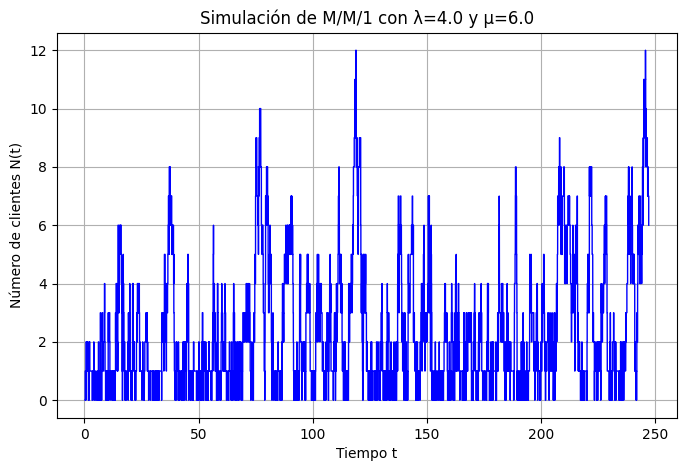

In [81]:
plt.figure(figsize=(8,5))

plt.step(X, Y, where="post", color="blue", linewidth=1)

plt.ylabel('Número de clientes N(t)')
plt.xlabel('Tiempo t')
plt.title(f"Simulación de M/M/1 con λ={lamda} y μ={mu}")
plt.grid(True)

plt.show()

**Fórmulas teóricas del modelo M/M/1**


\begin{array}{|c|c|}
\hline
\textbf{Parametro} & \textbf{Formula teorica} \\ \hline
L   & \frac{\lambda}{\mu - \lambda} \\ \hline
L_q & \frac{\lambda^{2}}{\mu(\mu - \lambda)} \\ \hline
W   & \frac{1}{\mu - \lambda} \\ \hline
W_q & \frac{\lambda}{\mu(\mu - \lambda)} \\ \hline
P_n & (1-\rho)\rho^n \\ \hline
\end{array}

Donde:
* $λ$ es la tasa de arribo (1/tpll)

* $\mu$ es la tasa de servicio (1/tps)

* $\rho = \frac{λ}{μ}$ es el factor de utilización

In [88]:

rho = lamda / mu
# Primero checar condición que rho < 1 para que no colapse el sistema
if rho >= 1:
    print("\n el sistema es inestable (rho >= 1)")
else:
    L_teo  = lamda / (mu - lamda)
    Lq_teo = (lamda**2) / (mu * (mu - lamda))
    W_teo  = 1 / (mu - lamda)
    Wq_teo = lamda / (mu * (mu - lamda))

    print(f"rho = {rho:.4f}")

    print(f"\nNúmero promedio de Clientes en el Sistema (Resultado analítico): \n L = {L_teo:.4f}")
    print(f"Número promedio de Clientes en la Fila (Resultado analítico): \n Lq = {Lq_teo:.4f}")
    print(f"Tiempo promedio en el Sistema (Resultado analítico): \n W = {W_teo:.4f}")
    print(f"Tiempo promedio en la Fila (Resultado analítico): \n Wq = {Wq_teo:.4f}")

    print("\nProbabilidades teóricas:")
    for n in range(0, 10):
        print(f"P({n}) = {(1-rho)*rho**n:.4f}")

rho = 0.6667

Número promedio de Clientes en el Sistema (Resultado analítico): 
 L = 2.0000
Número promedio de Clientes en la Fila (Resultado analítico): 
 Lq = 1.3333
Tiempo promedio en el Sistema (Resultado analítico): 
 W = 0.5000
Tiempo promedio en la Fila (Resultado analítico): 
 Wq = 0.3333

Probabilidades teóricas:
P(0) = 0.3333
P(1) = 0.2222
P(2) = 0.1481
P(3) = 0.0988
P(4) = 0.0658
P(5) = 0.0439
P(6) = 0.0293
P(7) = 0.0195
P(8) = 0.0130
P(9) = 0.0087


**Compraración de resultados**

In [95]:
diff_L   = abs(L_teo  - L)
diff_Lq  = abs(Lq_teo - Lq)
diff_W   = abs(W_teo  - W)

print(f"ΔL  = {diff_L:.6f}")
print(f"ΔLq = {diff_Lq:.6f}")
print(f"ΔW  = {diff_W:.6f}")



ΔL  = 0.187487
ΔLq = 0.155743
ΔW  = 0.034697
